In [1]:
!pip uninstall -y torchaudio torchvision

In [2]:

!pip install -q --upgrade pip

In [3]:
!pip install -q --upgrade "transformers>=4.40.0" accelerate datasets bitsandbytes matplotlib

In [4]:
# =====================================================================
# CELL 2: MODEL INITIALIZATION & VERIFICATION
# =====================================================================
import gc
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

TEACHER_MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
STUDENT_MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[Hardware Check] Execution Device: {device}")

# 1. Initialize Shared Tokenizer
print("\n[Loading Tokenizer] Shared Tokenizer for Qwen2.5 Family...")
tokenizer = AutoTokenizer.from_pretrained(TEACHER_MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

# 2. Load Teacher Model (1.5B) - Frozen FP16
print(f"[Loading Teacher] Model: {TEACHER_MODEL_ID} (FP16)...")
teacher_model = AutoModelForCausalLM.from_pretrained(
    TEACHER_MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
for param in teacher_model.parameters():
    param.requires_grad = False
teacher_model.eval()

# 3. Load Student Model (0.5B) - Trainable FP32 (Full Precision Master Weights)
print(f"[Loading Student] Model: {STUDENT_MODEL_ID} (FP32 Trainable)...")
student_model = AutoModelForCausalLM.from_pretrained(
    STUDENT_MODEL_ID,
    torch_dtype=torch.float32,
    device_map="auto",
    trust_remote_code=True,
)

total_mem_used = torch.cuda.memory_allocated() / (1024**3)
print(f"[VRAM Profiling] Models Loaded. Total Allocated VRAM: {total_mem_used:.2f} GB")
print("[Status] Model loading complete!")

[Hardware Check] Execution Device: cuda

[Loading Tokenizer] Shared Tokenizer for Qwen2.5 Family...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


[Loading Teacher] Model: Qwen/Qwen2.5-1.5B-Instruct (FP16)...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[Loading Student] Model: Qwen/Qwen2.5-0.5B-Instruct (FP32 Trainable)...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[VRAM Profiling] Models Loaded. Total Allocated VRAM: 4.72 GB
[Status] Model loading complete!


# What We Are Building in Cell 3

This cell implements four major components:

1. Teacher-Mixed Sampling
2. Single-Step Reverse KL Reward
3. Single-Step Token-Level Reverse KL Loss
4. Length-Normalized Policy Loss

---

# 1. Teacher-Mixed Sampling ($\tilde{p}$)

Instead of sampling only from the student model, MiniLLM samples from a **mixture distribution** of the teacher and student.

The sampling distribution is

$$
\tilde{p}(y_t \mid y_{<t}, x)
=
\alpha \cdot p(y_t \mid y_{<t}, x)
+
(1-\alpha)\cdot q_\theta(y_t \mid y_{<t}, x)
$$

where

- $p(\cdot)$ = Teacher distribution
- $q_\theta(\cdot)$ = Student distribution
- $\alpha = 0.2$

The paper recommends

$$
\alpha = 0.2
$$

to suppress degenerate reward-hacking while still allowing the student to explore.

---

# 2. Single-Step Token-Level Reverse-KL Reward ($r_t$)

For every generated token, the reward is simply the log-probability difference between teacher and student.

$$
r_t
=
\log p_{\text{teacher}}
(y_t \mid y_{<t}, x)
-
\log q_{\text{student}}
(y_t \mid y_{<t}, x)
$$

Interpretation:

- Positive reward → Teacher assigns higher probability than student.
- Negative reward → Student is already more confident than teacher.

This reward becomes the basic signal used in policy optimization.

---

# 3. Single-Step Decomposition

Instead of estimating gradients using noisy Monte-Carlo sampling, MiniLLM computes the exact expectation over the **Top-K vocabulary**.

The objective becomes

$$
(\nabla \mathcal{L})_{\text{Single}}
=
-
\sum_{t=1}^{T}
w_t
\nabla_\theta
\sum_{v \in V}
q_\theta(v \mid y_{<t}, x)
\log
\frac{
p(v \mid y_{<t}, x)
}{
q_\theta(v \mid y_{<t}, x)
}
$$

where

- $V$ = Top-K vocabulary
- $w_t$ = token weight
- $q_\theta$ = Student distribution
- $p$ = Teacher distribution

Computing the expectation exactly over the Top-K vocabulary dramatically reduces policy-gradient variance.

---

# 4. Length-Normalized Policy Loss

MiniLLM computes downstream advantages using future rewards.

The normalized return is

$$
R_{t+1}^{\text{Norm}}
=
\frac{1}{T-t-1}
\sum_{t'=t+1}^{T}
r_{t'}
$$

where

- $T$ = sequence length
- $r_{t'}$ = future token rewards

Instead of summing rewards directly, MiniLLM averages them over the remaining sequence.

This normalization prevents the model from exploiting shorter responses (including empty responses) simply because they accumulate fewer negative rewards.

In [5]:
# =====================================================================
# CELL 3: HONEST & EOS-AWARE MINILLM ENGINE
# =====================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class MiniLLMDistillationTrainer:
    def __init__(
        self,
        teacher_model: nn.Module,
        student_model: nn.Module,
        tokenizer,
        optimizer: torch.optim.Optimizer,
        alpha: float = 0.2,            # Teacher mix-in strength
        temperature: float = 1.0,      # Sampling temperature
        top_k_single_step: int = 50,   # Vocabulary range for L_Single
    ):
        self.teacher = teacher_model
        self.student = student_model
        self.tokenizer = tokenizer
        self.optimizer = optimizer
        self.alpha = alpha
        self.temperature = temperature
        self.top_k = top_k_single_step
        self.device = next(student_model.parameters()).device
        self.eos_token_id = tokenizer.eos_token_id

    @torch.no_grad()
    def teacher_mixed_sample_step(
        self,
        student_logits: torch.Tensor,
        teacher_logits: torch.Tensor
    ) -> torch.Tensor:
        """Samples next token on-policy from mixture: p_tilde = alpha * p_teacher + (1 - alpha) * q_student"""
        s_logits = student_logits.float() / self.temperature
        t_logits = teacher_logits.float() / self.temperature

        p_teacher = F.softmax(t_logits, dim=-1)
        q_student = F.softmax(s_logits, dim=-1)

        p_tilde = self.alpha * p_teacher + (1.0 - self.alpha) * q_student
        p_tilde = p_tilde / p_tilde.sum(dim=-1, keepdim=True)

        return torch.multinomial(p_tilde, num_samples=1)

    def compute_minillm_loss(self, prompt_ids: torch.Tensor, gen_len: int = 16):
        self.student.train()
        batch_size, prompt_len = prompt_ids.shape
        curr_seq = prompt_ids.clone()

        # -----------------------------------------------------------------
        # 1. ON-POLICY ROLLOUT GENERATION WITH EOS EARLY STOPPING
        # -----------------------------------------------------------------
        seq_active = torch.ones(batch_size, dtype=torch.bool, device=self.device)
        eos_mask_list = []

        with torch.no_grad():
            for _ in range(gen_len):
                t_logits = self.teacher(curr_seq).logits[:, -1, :]
                s_logits = self.student(curr_seq).logits[:, -1, :]

                next_tok = self.teacher_mixed_sample_step(s_logits, t_logits)

                # Track valid token vs EOS padding
                eos_mask_list.append(seq_active.clone().float())

                # Check for EOS token
                is_eos = (next_tok.squeeze(-1) == self.eos_token_id)
                seq_active = seq_active & (~is_eos)

                curr_seq = torch.cat([curr_seq, next_tok], dim=1)

        full_seq = curr_seq
        gen_seq = full_seq[:, prompt_len:]
        loss_mask = torch.stack(eos_mask_list, dim=1)  # [batch, gen_len]

        # -----------------------------------------------------------------
        # 2. LOG-PROBABILITIES & HONEST NON-FINITE CHECK
        # -----------------------------------------------------------------
        with torch.no_grad():
            t_full_logits = self.teacher(full_seq).logits[:, prompt_len - 1 : -1, :].float() / self.temperature
            t_log_probs = F.log_softmax(t_full_logits, dim=-1)

        s_full_logits = self.student(full_seq).logits[:, prompt_len - 1 : -1, :].float() / self.temperature

        # DIAGNOSTIC CHECK: Catch instability honestly instead of silent nan_to_num masking
        if torch.isnan(s_full_logits).any() or torch.isinf(s_full_logits).any():
            print("[WARN] Non-finite student logits detected — skipping optimizer step.")
            return {
                "loss_total": float("nan"),
                "loss_single": float("nan"),
                "loss_long": float("nan"),
                "mean_reward": float("nan")
            }

        s_log_probs = F.log_softmax(s_full_logits, dim=-1)
        s_probs = F.softmax(s_full_logits, dim=-1)

        gen_tokens_unsq = gen_seq.unsqueeze(-1)
        q_tok_logprob = torch.gather(s_log_probs, -1, gen_tokens_unsq).squeeze(-1)
        p_tok_logprob = torch.gather(t_log_probs, -1, gen_tokens_unsq).squeeze(-1)

        # Importance Sampling Weights w_t ≈ q_student / p_tilde
        with torch.no_grad():
            q_tok_prob = torch.exp(q_tok_logprob)
            p_tok_prob = torch.exp(p_tok_logprob)
            p_tilde_prob = self.alpha * p_tok_prob + (1.0 - self.alpha) * q_tok_prob
            w_t = torch.clamp(q_tok_prob / (p_tilde_prob + 1e-8), min=0.1, max=2.0)

        # -----------------------------------------------------------------
        # 3. SINGLE-STEP DECOMPOSITION LOSS (L_Single)
        # -----------------------------------------------------------------
        topk_p_log, topk_idx = torch.topk(t_log_probs, k=self.top_k, dim=-1)
        topk_q_log = torch.gather(s_log_probs, -1, topk_idx)
        topk_q_prob = torch.gather(s_probs, -1, topk_idx)

        single_step_kl = (topk_q_prob * (topk_q_log - topk_p_log)).sum(dim=-1)
        loss_single = ((w_t * single_step_kl) * loss_mask).sum() / (loss_mask.sum() + 1e-8)

        # -----------------------------------------------------------------
        # 4. LENGTH-NORMALIZED POLICY LOSS (L_Long_Norm)
        # -----------------------------------------------------------------
        with torch.no_grad():
            r_t = (p_tok_logprob - q_tok_logprob) * loss_mask  # Masked reward: log p - log q

            R_norm = torch.zeros_like(r_t)
            for t_idx in range(gen_len - 1):
                # Masked mean over future active tokens
                future_mask = loss_mask[:, t_idx + 1 :]
                future_rewards = r_t[:, t_idx + 1 :] * future_mask
                denom = future_mask.sum(dim=-1).clamp(min=1.0)
                R_norm[:, t_idx] = future_rewards.sum(dim=-1) / denom

            # Advantage baseline subtraction over active tokens
            active_rewards = R_norm * loss_mask
            mean_adv = active_rewards.sum(dim=-1, keepdim=True) / (loss_mask.sum(dim=-1, keepdim=True) + 1e-8)
            advantages = (R_norm - mean_adv) * loss_mask

        loss_long = -((w_t * advantages * q_tok_logprob) * loss_mask).sum() / (loss_mask.sum() + 1e-8)

        # -----------------------------------------------------------------
        # 5. GRADIENT UPDATE & WEIGHT CLIPPING
        # -----------------------------------------------------------------
        total_loss = loss_single + loss_long

        self.optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.student.parameters(), max_norm=0.5)
        self.optimizer.step()

        active_tokens_count = loss_mask.sum().item()
        mean_r = (r_t.sum() / active_tokens_count).item() if active_tokens_count > 0 else 0.0

        return {
            "loss_total": total_loss.item(),
            "loss_single": loss_single.item(),
            "loss_long": loss_long.item(),
            "mean_reward": mean_r,
        }

print("[Status] Honest & EOS-Aware Engine ready!")

[Status] Honest & EOS-Aware Engine ready!


In [6]:
# =====================================================================
# CELL 4: DATASET PIPELINE & 300-STEP EXECUTION LOOP
# =====================================================================
import time
from datasets import load_dataset

# 1. Load Instruction Dataset
print("[Dataset Pipeline] Loading Instruction Dataset...")
raw_dataset = load_dataset("databricks/databricks-dolly-15k", split="train[:50]")

def format_prompt(instruction: str, context: str = "") -> str:
    if context:
        prompt_text = f"Context: {context}\nInstruction: {instruction}"
    else:
        prompt_text = instruction
    return f"<|im_start|>user\n{prompt_text}<|im_end|>\n<|im_start|>assistant\n"

formatted_prompts = [
    format_prompt(item["instruction"], item["context"]) for item in raw_dataset
]

tokenized_prompts = [
    tokenizer(p, return_tensors="pt", truncation=True, max_length=128).input_ids.to(device)
    for p in formatted_prompts
]

# 2. Setup Student Optimizer (lr=5e-6 matching MiniLLM Paper)
optimizer = torch.optim.AdamW(student_model.parameters(), lr=5e-6, weight_decay=0.01)

trainer = MiniLLMDistillationTrainer(
    teacher_model=teacher_model,
    student_model=student_model,
    tokenizer=tokenizer,
    optimizer=optimizer,
    alpha=0.2,            # Teacher mix-in strength
    temperature=1.0,      # Sampling temperature
    top_k_single_step=50, # Vocabulary sum range
)

# 3. Metric Tracking
history = {
    "step": [],
    "loss_total": [],
    "loss_single": [],
    "loss_long": [],
    "mean_reward": [],
}

num_steps = 300
gen_length = 16  # Rollout sequence length per step

print("\n" + "="*65)
print("STARTING MINILLM ON-POLICY DISTILLATION LOOP (300 STEPS)")
print("="*65)

start_time = time.time()
for step in range(num_steps):
    prompt_batch = tokenized_prompts[step % len(tokenized_prompts)]

    # Compute step loss & update student weights
    metrics = trainer.compute_minillm_loss(prompt_ids=prompt_batch, gen_len=gen_length)

    # Store history
    history["step"].append(step + 1)
    history["loss_total"].append(metrics["loss_total"])
    history["loss_single"].append(metrics["loss_single"])
    history["loss_long"].append(metrics["loss_long"])
    history["mean_reward"].append(metrics["mean_reward"])

    if (step + 1) % 20 == 0 or step == 0:
        vram_used = torch.cuda.memory_allocated() / (1024**3)
        print(
            f"Step {step + 1:03d}/{num_steps:03d} | "
            f"Total Loss: {metrics['loss_total']:8.4f} | "
            f"L_Single: {metrics['loss_single']:8.4f} | "
            f"L_Long: {metrics['loss_long']:8.4f} | "
            f"Mean Reward (r_t): {metrics['mean_reward']:8.4f} | "
            f"VRAM: {vram_used:.2f} GB"
        )

elapsed = time.time() - start_time
print("="*65)
print(f"[Training Complete] Executed {num_steps} steps in {elapsed:.2f}s!")

[Dataset Pipeline] Loading Instruction Dataset...

STARTING MINILLM ON-POLICY DISTILLATION LOOP (300 STEPS)
Step 001/300 | Total Loss:   1.9525 | L_Single:   1.9527 | L_Long:  -0.0001 | Mean Reward (r_t):  -1.5945 | VRAM: 10.26 GB
Step 020/300 | Total Loss:   0.8557 | L_Single:   0.9644 | L_Long:  -0.1088 | Mean Reward (r_t):  -0.6977 | VRAM: 10.26 GB
Step 040/300 | Total Loss:   0.2820 | L_Single:   0.4717 | L_Long:  -0.1898 | Mean Reward (r_t):  -0.8103 | VRAM: 10.26 GB
Step 060/300 | Total Loss:   1.0910 | L_Single:   0.2054 | L_Long:   0.8857 | Mean Reward (r_t):  -0.9028 | VRAM: 10.26 GB
Step 080/300 | Total Loss:   0.7895 | L_Single:   0.4060 | L_Long:   0.3835 | Mean Reward (r_t):  -1.5189 | VRAM: 10.26 GB
Step 100/300 | Total Loss:   0.9847 | L_Single:   0.0323 | L_Long:   0.9524 | Mean Reward (r_t):  -1.6918 | VRAM: 10.26 GB
Step 120/300 | Total Loss:   0.2542 | L_Single:   0.2839 | L_Long:  -0.0297 | Mean Reward (r_t):   0.4071 | VRAM: 10.26 GB
Step 140/300 | Total Loss:   1.

In [7]:
# =====================================================================
# CELL 6: POST-DISTILLATION INFERENCE COMPARISON
# =====================================================================
print("\n" + "="*65)
print("POST-DISTILLATION INFERENCE EVALUATION")
print("="*65)

eval_prompt = "Write a short, professional email to a client named Sarah apologizing for a slight delay in delivering the Q3 financial report."
formatted_eval_prompt = f"<|im_start|>user\n{eval_prompt}<|im_end|>\n<|im_start|>assistant\n"

inputs = tokenizer(formatted_eval_prompt, return_tensors="pt").to(device)

# 1. Generate from the 1.5B Teacher (The Target)
with torch.no_grad():
    teacher_output_ids = teacher_model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=True,
        temperature=0.7,
        top_p=0.9
    )
teacher_response = tokenizer.decode(teacher_output_ids[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)

# 2. Generate from the 0.5B MiniLLM Student (The Distilled Model)
with torch.no_grad():
    student_output_ids = student_model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=True,
        temperature=0.7,
        top_p=0.9
    )
student_response = tokenizer.decode(student_output_ids[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)

print(f"\nPrompt: {eval_prompt}\n")
print(f"--- TEACHER (1.5B, Frozen Target) ---\n{teacher_response.strip()}\n")
print(f"--- STUDENT (0.5B, MiniLLM Distilled) ---\n{student_response.strip()}\n")
print("="*65)


POST-DISTILLATION INFERENCE EVALUATION

Prompt: Write a short, professional email to a client named Sarah apologizing for a slight delay in delivering the Q3 financial report.

--- TEACHER (1.5B, Frozen Target) ---
Subject: Apologies for Delays in Delivering Q3 Financial Report

Dear Ms. Sarah,

I hope this message finds you well.

Please accept my sincere apologies for any inconvenience caused by the delay in the delivery of our Q3 financial report. We are currently experiencing some technical difficulties that have delayed the finalization and distribution of the document.

We understand the importance of accurate and timely reporting, and we are working diligently to resolve these issues as soon as possible. In the meantime, I would like

--- STUDENT (0.5B, MiniLLM Distilled) ---
random programming continue computer thank programming mathematics prefer age paid are programming internet programming software years copy programming shared remember programming computers wait work progr

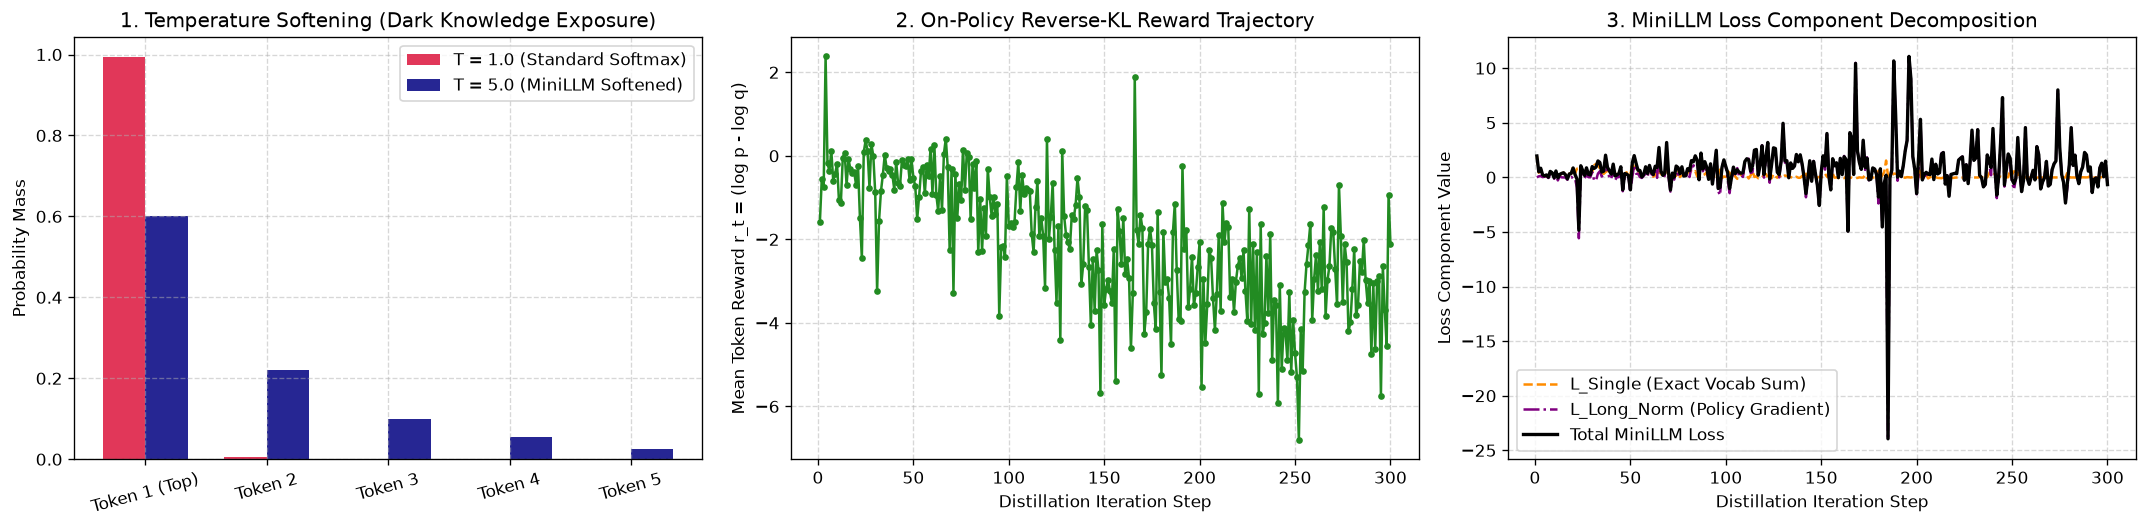

In [8]:
# =====================================================================
# CELL: VISUALIZE DIAGNOSTIC PLOTS DIRECTLY IN NOTEBOOK
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure grid directly in notebook display memory
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), dpi=120)

# ---------------------------------------------------------------------
# PLOT 1: Temperature Softening Comparison (T=1 vs T=5)
# ---------------------------------------------------------------------
sample_logits = torch.tensor([12.0, 7.0, 3.0, 0.0, -4.0])
p_t1 = F.softmax(sample_logits / 1.0, dim=-1).numpy()
p_t5 = F.softmax(sample_logits / 5.0, dim=-1).numpy()

labels = ["Token 1 (Top)", "Token 2", "Token 3", "Token 4", "Token 5"]
x_indices = np.arange(len(labels))
width = 0.35

axes[0].bar(x_indices - width/2, p_t1, width, label="T = 1.0 (Standard Softmax)", color="crimson", alpha=0.85)
axes[0].bar(x_indices + width/2, p_t5, width, label="T = 5.0 (MiniLLM Softened)", color="navy", alpha=0.85)
axes[0].set_xticks(x_indices)
axes[0].set_xticklabels(labels, rotation=15)
axes[0].set_ylabel("Probability Mass")
axes[0].set_title("1. Temperature Softening (Dark Knowledge Exposure)")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# ---------------------------------------------------------------------
# PLOT 2: MiniLLM Token-Level Reverse-KL Reward Trajectory (r_t)
# ---------------------------------------------------------------------
axes[1].plot(history["step"], history["mean_reward"], marker="o", color="forestgreen", linewidth=1.5, markersize=3)
axes[1].set_xlabel("Distillation Iteration Step")
axes[1].set_ylabel("Mean Token Reward r_t = (log p - log q)")
axes[1].set_title("2. On-Policy Reverse-KL Reward Trajectory")
axes[1].grid(True, linestyle="--", alpha=0.5)

# ---------------------------------------------------------------------
# PLOT 3: MiniLLM Loss Decomposition (L_Single vs L_Long)
# ---------------------------------------------------------------------
axes[2].plot(history["step"], history["loss_single"], label="L_Single (Exact Vocab Sum)", color="darkorange", linestyle="--")
axes[2].plot(history["step"], history["loss_long"], label="L_Long_Norm (Policy Gradient)", color="purple", linestyle="-.")
axes[2].plot(history["step"], history["loss_total"], label="Total MiniLLM Loss", color="black", linewidth=2.0)
axes[2].set_xlabel("Distillation Iteration Step")
axes[2].set_ylabel("Loss Component Value")
axes[2].set_title("3. MiniLLM Loss Component Decomposition")
axes[2].legend()
axes[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

# Display inline directly without saving to disk
plt.show()